# Bài tập 3: Dự báo chuỗi thời gian sử dụng ARIMA

Dataset: `Data.xls`

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")



def adf_test(x):
    indices = ['ADF: Test statistic', 'p value', '# of Lags', '# of Observations']

    test = adfuller(x, autolag='AIC') # Perform

    #Dickey-Fuller test

    results = pd.Series(test[:4], index=indices)
    
    for key, value in test[4].items():

        results[f'Critical Value ({key})'] = value
        
    if results['p value'] <= 0.05: # (p-value < 0.05 (alpha=5%))

        print("Reject the null hypothesis (H0), \nthe data is stationary.")

    else:

        print("Fail to reject the null hypothesis (HO), \nthe data is not stationary.")
    
    return results

def kpss_test(x):
    indices = ['KPSS: Test statistic', 'p value', '# of Lags']

    test = kpss(x)

    results = pd.Series(test[:3], index=indices)

    for key, value in test[3].items():

        results[f'Critical Value ({key})'] = value

    if results['p value'] <= 0.05: # (p-value < 0.05 (alpha=5%))

        print("Reject the null hypothesis (H0), \nthe data is not stationary.")

    else:

        print("Fail to reject the null hypothesis (HO), \nthe data is stationary.")
    return results

## 1. Load và Khám phá Dữ liệu

<Axes: title={'center': 'Time Series Data (Data.xls)'}, xlabel='Date'>

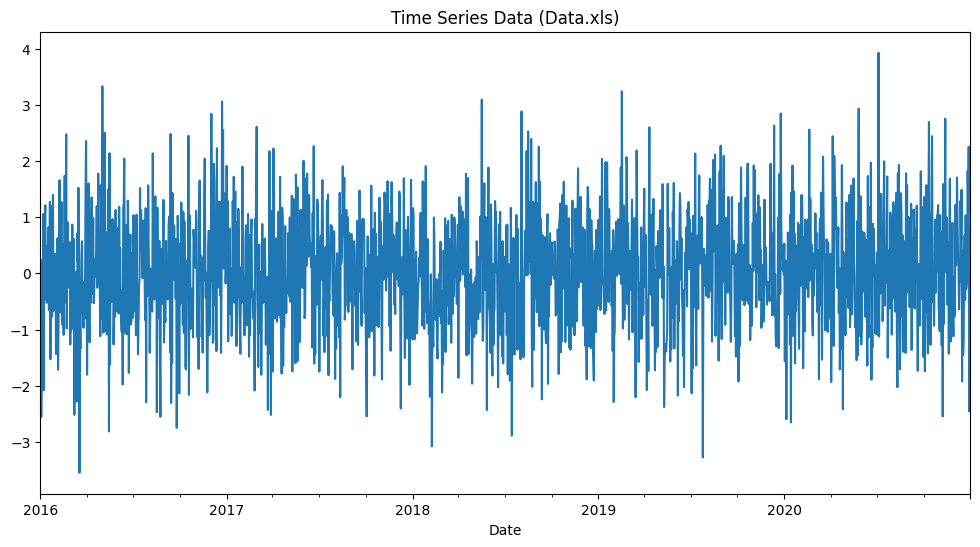

In [10]:
df = pd.read_excel('data/Data.xls', index_col='Date', parse_dates=True)
df = df.resample('D').ffill()
df['Value'].plot(figsize=(12,6), title='Time Series Data (Data.xls)')

## a) Phân rã dữ liệu (Decomposition) và Nhận xét

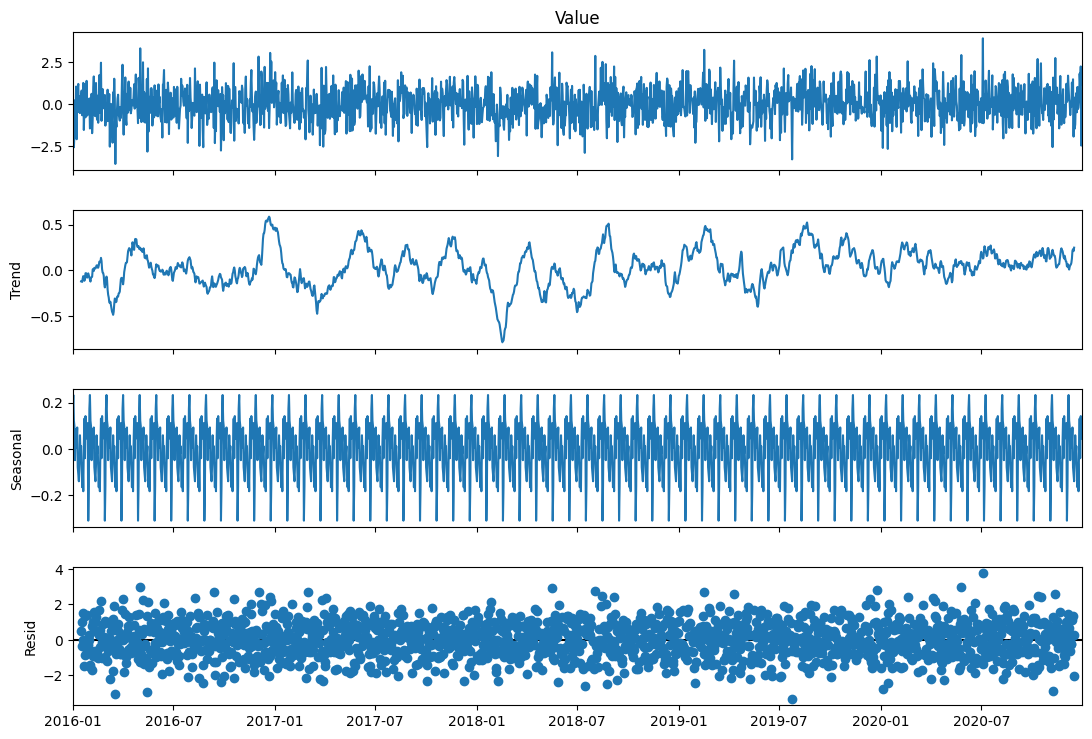

In [11]:
decomposition = seasonal_decompose(df['Value'], model='additive', period=30)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

## b) Kiểm định tính dừng và Tương quan

Reject the null hypothesis (H0), 
the data is stationary.
ADF Test: ADF: Test statistic      -43.509372
p value                    0.000000
# of Lags                  0.000000
# of Observations       1826.000000
Critical Value (1%)       -3.433936
Critical Value (5%)       -2.863124
Critical Value (10%)      -2.567613
dtype: float64
Reject the null hypothesis (H0), 
the data is not stationary.

KPSS Test: KPSS: Test statistic     0.544902
p value                  0.031553
# of Lags                2.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64


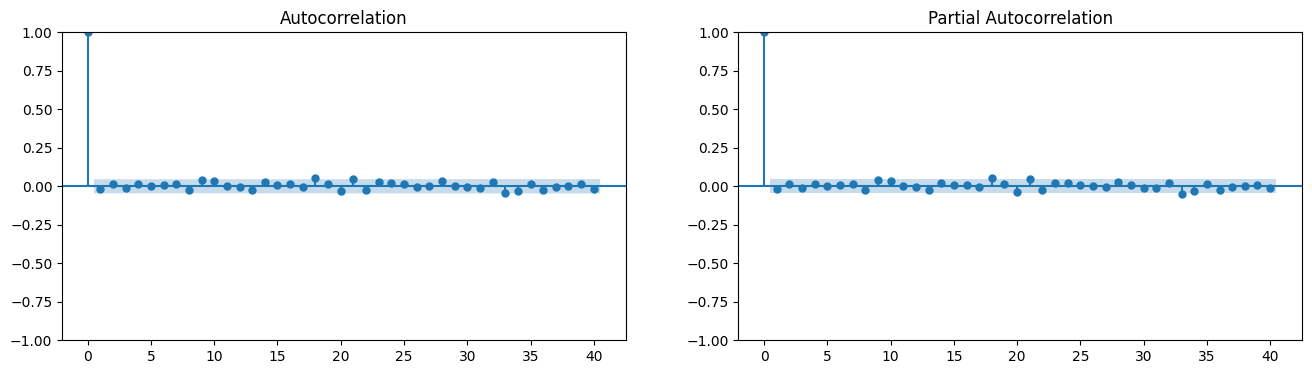

In [15]:
print("ADF Test:", adf_test(df['Value']))
print("\nKPSS Test:", kpss_test(df['Value']))

# ACF and PACF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df['Value'], ax=ax1, lags=40)
plot_pacf(df['Value'], ax=ax2, lags=40)
plt.show()